<a href="https://colab.research.google.com/github/seom0323-web/Computational-Physics-Newman/blob/main/ComputationalPhysics(PDE).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#편미분방정식(Partial Diffrential Equations)

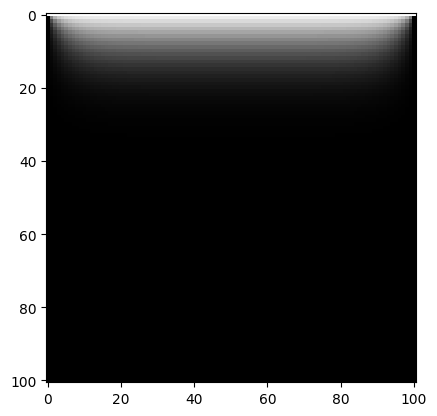

In [ ]:
#야코비 이완법(Jacobi Relaxation Method)
import numpy as np
import matplotlib.pyplot as plt

M=100
V=1.0
tol=1e-3

phi=np.zeros([M+1,M+1],float)
phi[0,:]=V
phiprime=np.empty([M+1,M+1],float)

delta=1.0
while delta>tol:
  for i in range(M+1):
    for j in range(M+1):
      if i==0 or i==M or j==0 or j==M:
        phiprime[i,j]=phi[i,j]
      else:
        phiprime[i,j]=0.25*(phi[i+1,j]+phi[i-1,j] \
                            +phi[i,j+1]+phi[i,j-1])
    delta=np.max(np.abs(phi-phiprime))
    phi,phiprime=phiprime,phi

plt.imshow(phi)
plt.gray()
plt.show()

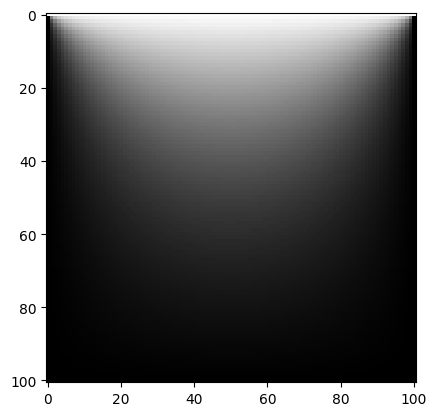

In [ ]:
#Gauss-Sidel Method
import numpy as np
import matplotlib.pyplot as plt

M=100
V=1.0
tol=1e-6

phi=np.zeros([M+1,M+1],float)
phi[0,:]=V

while delta>tol:
  delta=0.0
  for ii in range(M-1):
    for jj in range(M-1):
      i=ii+1
      j=jj+1
      tmp=0.25*(phi[i+1,j]+phi[i-1,j]+phi[i,j+1]+phi[i,j-1])
      delta=max(delta,np.abs(phi[i,j]-tmp))
      phi[i,j]=tmp
plt.imshow(phi)
plt.gray()
plt.show()

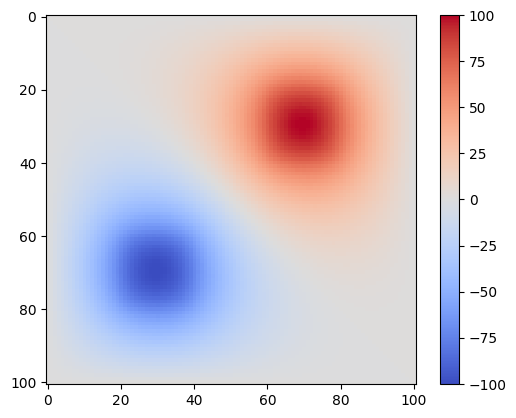

In [ ]:
#Poisson Equation

import numpy as np
import matplotlib.pyplot as plt

M=100
V=1.0
tol=1e-6

phi=np.zeros((M+1,M+1))
rho=np.zeros_like(phi)
rho[60:80,20:40]=-V
rho[20:40,60:80]=V

delta=1.0
while delta>tol:
  delta=0.0
  for ii in range(M-1):
    for jj in range(M-1):
      i=ii+1
      j=jj+1
      tmp=0.25*((phi[i+1,j]+phi[i-1,j]+phi[i,j+1]+phi[i,j-1])+rho[i,j])
      delta=max(delta,np.abs(phi[i,j]-tmp))
      phi[i,j]=tmp
plt.imshow(phi,cmap='coolwarm')
plt.colorbar()
plt.show()








[50.         49.49698463 48.99397225 48.4909658  47.98796828 47.48498263
 46.9820118  46.47905873 45.97612632 45.47321747 44.97033506 44.46748192
 43.96466088 43.46187471 42.95912617 42.45641797 41.95375278 41.45113323
 40.94856192 40.44604136 39.94357406 39.44116245 38.93880891 38.43651575
 37.93428525 37.43211961 36.93002096 36.42799137 35.92603284 35.42414732
 34.92233666 34.42060264 33.91894698 33.41737131 32.91587719 32.41446609
 31.9131394  31.41189844 30.91074442 30.40967849 29.9087017  29.40781501
 28.9070193  28.40631535 27.90570385 27.40518542 26.90476055 26.40442968
 25.90419312 25.40405112 24.9040038  24.40405122 23.90419333 23.40442999
 22.90476096 22.40518593 21.90570446 21.40631605 20.90702009 20.4078159
 19.90870267 19.40967955 18.91074555 18.41189964 17.91314068 17.41446743
 16.91587858 16.41737276 15.91894847 15.42060417 14.92233823 14.42414892
 13.92603447 13.42799301 12.9300226  12.43212126 11.9342869  11.43651739
 10.93881053 10.44116405  9.94357563  9.4460429   8.

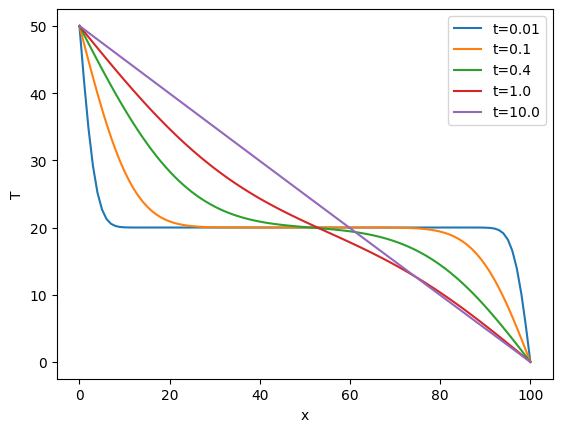

In [ ]:
#Initial Value Problems(초기값 문제,열 방정식)
import numpy as np
import matplotlib.pyplot as plt

L=0.01
D=4.25e-6
N=100
a=L/N
h=1e-4
epsilon=h/1000

Tlo=0.0
Tmid=20.0
Thi=50.0

t1=0.01
t2=0.1
t3=0.4
t4=1.0
t5=10.0
tend=t5+epsilon

T=np.empty(N+1,float) #경계조건 설정
T[0]=Thi
T[N]=Tlo
T[1:N]=Tmid
Tp=np.empty(N+1,float)
Tp[0]=Thi
Tp[N]=Tlo

t=0.0
c=h*D/(a*a)
while t<tend:
  for i in range(1,N):
    Tp[i]=T[i]+c*(T[i+1]+T[i-1]-2*T[i])
  T,Tp=Tp,T
  t+=h
  if abs(t-t1)<epsilon:
    plt.plot(T,label='t=0.01')
  if abs(t-t2)<epsilon:
    plt.plot(T,label='t=0.1')
  if abs(t-t3)<epsilon:
    plt.plot(T,label='t=0.4')
  if abs(t-t4)<epsilon:
    plt.plot(T,label='t=1.0')
  if abs(t-t5)<epsilon:
    plt.plot(T,label='t=10.0')

plt.xlabel('x')
plt.ylabel('T')
plt.legend()
plt.show()

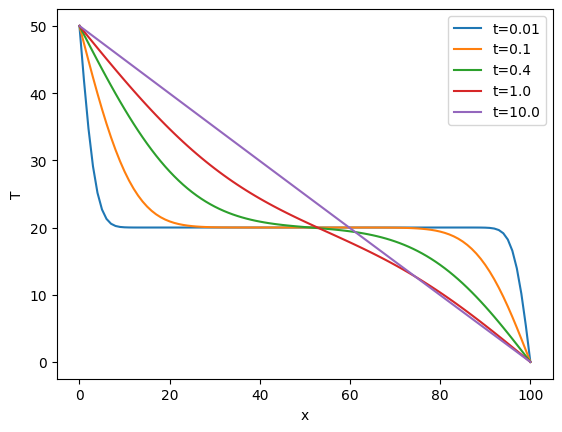

In [ ]:
#Crank-Nicolson Method(열 방정식)
import numpy as np
import matplotlib.pyplot as plt

L=0.01
D=4.25e-6
N=100
a=L/N
h=1e-4
epsilon=h/1000.0

Tlo=0.0
Tmid=20.0
Thi=50.0

t1=0.01
t2=0.1
t3=0.4
t4=1.0
t5=10.0
tend=t5+epsilon

T=np.empty(N+1,float)
T[0]=Thi
T[N]=Tlo
T[1:N]=Tmid
Tp=np.empty(N+1,float)
Tp[0]=Thi
Tp[N]=Tlo

LHS=2.0+2.0*a*a/(h*D)
RHS=-2.0+2.0*a*a/(h*D)

M=np.zeros((N-1,N-1))
np.fill_diagonal(M,LHS)
np.fill_diagonal(M[1:,:],-1)
np.fill_diagonal(M[:,1:],-1)
t=0.0
while t<tend:
  Tp[1:-1]=T[:-2]+RHS*T[1:-1]+T[2:]
  Tp[1]+=T[0]
  Tp[-2]+=T[-1]
  Tp[1:-1]=np.linalg.solve(M,Tp[1:-1])
  T,Tp=Tp,T
  t+=h
  if abs(t-t1)<epsilon:
    plt.plot(T,label='t=0.01')
  if abs(t-t2)<epsilon:
    plt.plot(T,label='t=0.1')
  if abs(t-t3)<epsilon:
    plt.plot(T,label='t=0.4')
  if abs(t-t4)<epsilon:
    plt.plot(T,label='t=1.0')
  if abs(t-t5)<epsilon:
    plt.plot(T,label='t=10.0')

plt.xlabel('x')
plt.ylabel('T')
plt.legend()
plt.show()


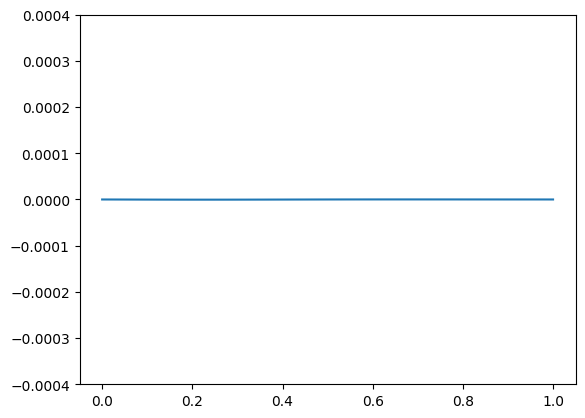

In [ ]:
#파동방정식
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

L=1.0
d=0.1
C=1.0
sig=0.3
v=100.0

N=100
a=L/N
h=0.000001
eta=h*(v/a)**2


x=np.arange(0.0,L+0.001*a,a)
psi=C*((x*(L-x))/(L**2))*np.exp(-((x-d)**2)/(2*sig**2))
new_psi=np.zeros_like(psi)
phi=np.zeros_like(psi)
new_phi=np.zeros_like(phi)

t=0.0
tmax=0.02
phi_history=[]
count = 0
while t<tmax:
  if count % 200 == 0:
    phi_history.append(np.copy(phi))
  count += 1
  new_phi[1:-1]=phi[1:-1]+h*psi[1:-1]
  new_psi[1:-1]=psi[1:-1]+eta*(phi[2:]+phi[:-2]-2.0*phi[1:-1])
  phi,new_phi=new_phi,phi
  psi,new_psi=new_psi,psi
  t=t+h
phi[0]=phi[-1]=0.0
psi[0]=psi[-1]=0.0
fig,ax=plt.subplots()
ax.set_ylim(-0.0004,0.0004)
line, = ax.plot(x,phi_history[0])

def update(i):
  line.set_ydata(phi_history[i])
  return line,

anim=animation.FuncAnimation(fig, update, frames=len(phi_history), interval=30, blit=True)

from IPython.display import HTML
HTML(anim.to_jshtml())






Elapsed Time:-41.6963996887207


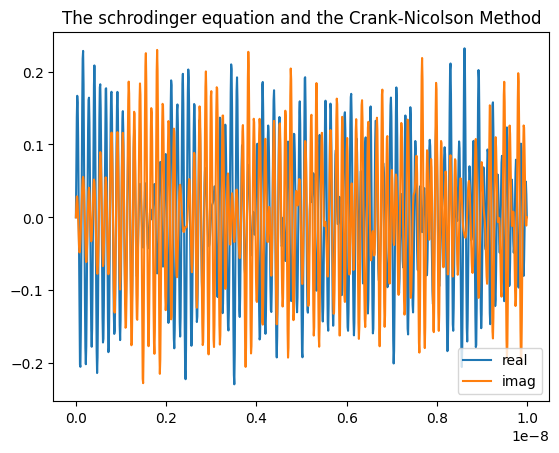

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cmath
import time

def banded(Aa,va,up,down):

    # Copy the inputs and determine the size of the system
    A = np.copy(Aa)
    v = np.copy(va)
    N = len(v)

    # Gaussian elimination
    for m in range(N):

        # Normalization factor
        div = A[up,m]

        # Update the vector first
        if div!=0:
          v[m] /= div
        else:
          v[m] = 0.0
        for k in range(1,down+1):
            if m+k<N:
                v[m+k] -= A[up+k,m]*v[m]
        # Now normalize the pivot row of A and subtract from lower ones
        for i in range(up):
            j = m + up - i
            if j<N:
              if div!=0:
                A[i,j] /= div
              else:
                A[i,j]=0.0
              for k in range(1,down+1):
                A[i+k,j] -= A[up+k,m]*A[i,j]

    # Backsubstitution
    for m in range(N-2,-1,-1):
        for i in range(up):
            j = m + up - i
            if j<N:
                v[m] -= A[i,j]*v[j]

    return v

L=1e-8
M=9.109e-31
x0=0.5*L
sig=1e-10
K=5e+10
N=1000
a=L/N
h=1e-18
hbar=1.054e-34

a1=1+h*((1j*hbar)/(2*M*a**2))
a2=-h*((1j*hbar)/(4*M*a**2))
b1=1-h*((1j*hbar)/(2*M*a**2))
b2=h*((1j*hbar)/(4*M*a**2))

# Correctly construct the banded matrix A_banded for the 'banded' function
# The system size is N-2 internal points.
size = N-2
A_banded = np.zeros((3, size), complex)

A_banded[1, :] = a1 # Main diagonal
A_banded[0, 1:] = a2 # Upper diagonal (shifted to the right by 1 in the matrix)
A_banded[2, :-1] = a2 # Lower diagonal (shifted to the left by 1 in the matrix)

x=np.arange(0,L,a)
psi=np.exp(-((x-x0)**2)/(2*sig**2))*np.exp(1j*K*x) #초기조건
psi_n=np.zeros_like(psi)
T=0.0
start_time=time.time()
count=0
skip=100
Tend=1e-14 # Shortened Tend from previous interaction
psi_history=[]
while T<Tend:
  if count % skip == 0:
    psi_history.append(np.copy(psi))
  count +=1
  psi_n[1:-1]=b1*psi[1:-1]+b2*(psi[2:]+psi[:-2])
  # Use the correctly formatted banded matrix
  psi_n[1:-1]=banded(A_banded,psi_n[1:-1],1,1)
  psi[0]=0.0
  psi[-1]=0.0
  psi,psi_n=psi_n,psi
  T+=h

end_time=time.time()
print(f"Elapsed Time:{start_time-end_time}")
plt.plot(x,psi.real,label='real') #실수
plt.plot(x,psi.imag,label='imag') #허수
plt.legend()
plt.title('The schrodinger equation and the Crank-Nicolson Method')
plt.show()

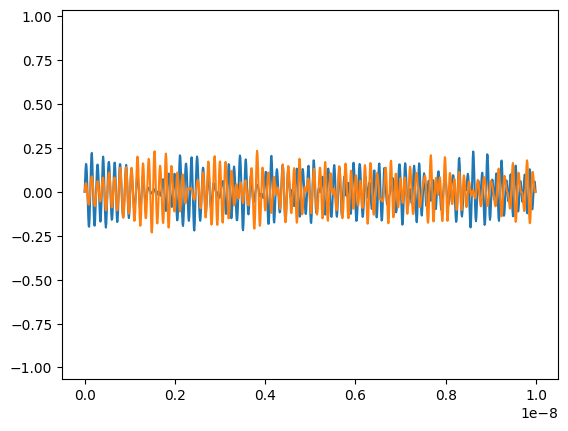

In [3]:
#animation(Time Evolution Of Schrodinger Equation)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML


fig,ax=plt.subplots()
line, = ax.plot(x,np.real(psi_history[0]))
line2, = ax.plot(x,np.imag(psi_history[0]))
def update(i):
  line.set_ydata(np.real(psi_history[i]))
  line2.set_ydata(np.imag(psi_history[i]))
  return line, line2

anim=FuncAnimation(fig, update, frames=len(psi_history), interval=100, blit=True)
HTML(anim.to_jshtml())

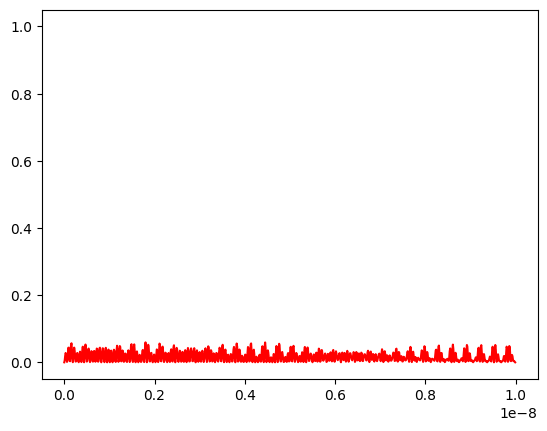

In [4]:
#확률 밀도 그래프 애니메이션
from matplotlib.animation import FuncAnimation

psip_history=[]
for i in range(len(psi_history)):
  result_psip=abs(psi_history[i])**2
  psip_history.append(result_psip)

fig,ax=plt.subplots()
pline, = ax.plot(x,psip_history[0],color='red')
def update(i):
  pline.set_ydata(psip_history[i])
  return pline,
anim=FuncAnimation(fig, update, frames=len(psi_history), interval=100, blit=True)
HTML(anim.to_jshtml())

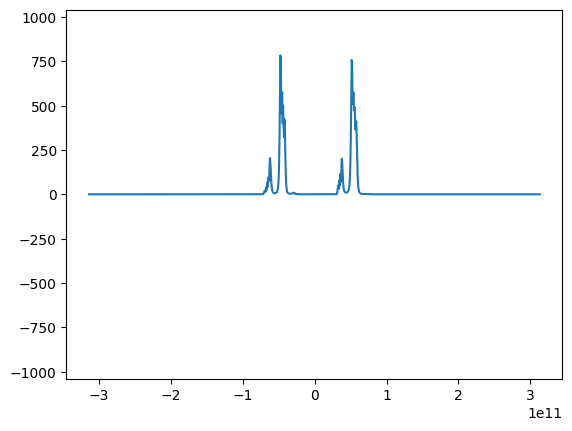

In [6]:
#운동량 애니메이션
import scipy.fft
import numpy as np
from matplotlib.animation import FuncAnimation

psim_history=[]
dx=a
for j in range(len(psi_history)):
  result_psim=scipy.fft.fft(psi_history[j])
  shifted_psim=scipy.fft.fftshift(result_psim)
  prob_density=np.abs(shifted_psim)**2
  psim_history.append(prob_density)
momentum=2*np.pi*scipy.fft.fftfreq(N,dx)
shifted_momentum=scipy.fft.fftshift(momentum)
fig,ax=plt.subplots()
max_val=np.max(np.abs(psim_history))
ax.set_ylim(-1.2 * max_val, 1.2 * max_val)
mline, = ax.plot(shifted_momentum,np.real(psim_history[0]))
def update(i):
  mline.set_ydata(np.real(psim_history[i]))
  return mline, mline2

anim=FuncAnimation(
    fig, update, frames=len(psi_history), interval=100, blit=True)
HTML(anim.to_jshtml())